# **Replace the standard MLP in each GPT-2 transformer block with a Mixture of Experts (MoE) (router network and a number of expert networks) and fine-tune on Infinity-Instruct (instruct-reponse dataset with domain labels)**

# Include auxiliary loss across all experts, condition the router network

Import

In [1]:
import torch
import torch.nn as nn
import copy

from transformers import AutoTokenizer, GPT2LMHeadModel, TrainingArguments, Trainer, DataCollatorForSeq2Seq

import datasets
from datasets import load_dataset

from google.colab import drive
import os

import time
import math
import numpy as np
import scipy.stats as stats
from collections import Counter
from torch.utils.data import DataLoader


Config

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# specify dataset save path
dataset_save_directory = "/content/drive/MyDrive/tokenized_infinity"

# specify training configs output path
training_save_directory = "./gpt2-moe-infinity"

# specify model save path
save_directory = "/content/drive/MyDrive/gpt2-moe-conditioned"


Mount Google Drive (to save/load tokenized dataset, model, etc)

In [3]:
drive.mount('/content/drive')

# create the folder if it does not already exist
os.makedirs(save_directory, exist_ok=True)

Mounted at /content/drive


Load base GPT2

In [4]:
# instantiate tokenizer
tokenizer = AutoTokenizer.from_pretrained('openai-community/gpt2')

# instantiate base pre-trained GPT2 model
model = GPT2LMHeadModel.from_pretrained('openai-community/gpt2')


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [5]:
# print model architecture of base GPT2 model
print(model)

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)


In [6]:
# look at parameters under the hood in the base GPT2 model
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

Total Parameters: 124,439,808
Trainable Parameters: 124,439,808


In [7]:
# print parameters names and shapes from base GPT2 model
for name, param in model.named_parameters():
    print(f"{name:50} | Shape: {str(param.shape):30} | Trainable: {param.requires_grad}")

transformer.wte.weight                             | Shape: torch.Size([50257, 768])       | Trainable: True
transformer.wpe.weight                             | Shape: torch.Size([1024, 768])        | Trainable: True
transformer.h.0.ln_1.weight                        | Shape: torch.Size([768])              | Trainable: True
transformer.h.0.ln_1.bias                          | Shape: torch.Size([768])              | Trainable: True
transformer.h.0.attn.c_attn.weight                 | Shape: torch.Size([768, 2304])        | Trainable: True
transformer.h.0.attn.c_attn.bias                   | Shape: torch.Size([2304])             | Trainable: True
transformer.h.0.attn.c_proj.weight                 | Shape: torch.Size([768, 768])         | Trainable: True
transformer.h.0.attn.c_proj.bias                   | Shape: torch.Size([768])              | Trainable: True
transformer.h.0.ln_2.weight                        | Shape: torch.Size([768])              | Trainable: True
transformer.h.0.ln_

In [8]:
# # test code for direct parameter modification

# # isolate the specific parameters to change (e.g., first token embedding layer; see list above)
# embedding_weights = model.transformer.wte.weight

# # manually adjust parameters
# # use in-place operations with underscore suffix (e.g., .mul_(), .add_(), .copy_()) to update underlying PyTorch data
# with torch.no_grad(): # disable gradient calculation / computation graph
#     # multiply all weights by a specific scalar factor (e.g., 1.5)
#     embedding_weights.mul_(1.5)

#     # another example, manually set a specific parameter tensor to a custom tensor
#     # new_weights = torch.randn_like(embedding_weights)
#     # embedding_weights.copy_(new_weights)

In [9]:
# set base GPT2 model to evaluation mode
model.eval()

# tokenize input
inputs = tokenizer('Hello, my dog is cute', return_tensors='pt')

# generate token outputs from model
outputs = model.generate(**inputs, max_length=20)

# detokenize output into readable text
generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

print(generated_text)


Hello, my dog is cute. I'm not sure if she's a puppy or not. I


In each transformer block of GPT, replace MLP with router network plus 4 experts

In [10]:

# create custom PyTorch module for the GPT2 MoE Layer
# add a router network (selects the expert model)
# and 4 experts
#
# also have routing logging to see which experts are being called

class GPT2MoELayer(nn.Module):
    def __init__(self, original_mlp, num_experts=4, aux_loss_coef=0.05):
        super().__init__()
        self.num_experts = num_experts
        self.aux_loss_coef = aux_loss_coef

        # Extract hidden dimension
        hidden_dim = original_mlp.c_fc.weight.shape[0]

        # Router network and expert clones
        self.router = nn.Linear(hidden_dim, num_experts)
        self.experts = nn.ModuleList([copy.deepcopy(original_mlp) for _ in range(num_experts)])

        # Tracking telemetry (safe for training, defaults to off)
        self.routing_log = []
        self.track_routing = False

        # Save routing probabilities for external loss calculation
        self.saved_router_probs = None

    def forward(self, hidden_states, attention_mask=None):
        orig_shape = hidden_states.shape
        flat_hidden_states = hidden_states.view(-1, orig_shape[-1])

        # Compute routing probabilities
        router_logits = self.router(flat_hidden_states)
        router_probs = torch.softmax(router_logits, dim=-1)

        # Save probabilities so the Trainer can calculate Aux Loss later
        if self.training:
            self.saved_router_probs = router_probs

        top1_weights, top1_indices = torch.topk(router_probs, k=1, dim=-1)
        flat_indices = top1_indices.squeeze(-1)

        # Log tokens during evaluation (Note: Without the patch, this will log padding too,
        # so use the Trainer's external mask logic if you want pure eval metrics!)
        if self.track_routing:
            self.routing_log.extend(flat_indices.tolist())

        # Execute expert computations
        flat_outputs = torch.zeros_like(flat_hidden_states)
        for expert_idx in range(self.num_experts):
            expert_mask = (flat_indices == expert_idx)
            if expert_mask.any():
                expert_inputs = flat_hidden_states[expert_mask]
                expert_outputs = self.experts[expert_idx](expert_inputs)
                flat_outputs[expert_mask] = expert_outputs * top1_weights[expert_mask]

        return flat_outputs.view(orig_shape)


In [11]:
# replace the MLPs in the transformer blocks

# Loop through each transformer layer and inject the MoE block
for i in range(len(model.transformer.h)):
    original_mlp = model.transformer.h[i].mlp
    moe_layer = GPT2MoELayer(original_mlp, num_experts=4)

    # Replace the default MLP layer with your custom MoE router/expert layer
    model.transformer.h[i].mlp = moe_layer

In [12]:
# look at new architecture

# Print the updated architecture of the first block to verify the swap
print(model.transformer.h[0])

# Recalculate parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nNew Total Parameters: {total_params:,}")

GPT2Block(
  (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (attn): GPT2Attention(
    (c_attn): Conv1D(nf=2304, nx=768)
    (c_proj): Conv1D(nf=768, nx=768)
    (attn_dropout): Dropout(p=0.1, inplace=False)
    (resid_dropout): Dropout(p=0.1, inplace=False)
  )
  (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (mlp): GPT2MoELayer(
    (router): Linear(in_features=768, out_features=4, bias=True)
    (experts): ModuleList(
      (0-3): 4 x GPT2MLP(
        (c_fc): Conv1D(nf=3072, nx=768)
        (c_proj): Conv1D(nf=768, nx=3072)
        (act): NewGELUActivation()
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
  )
)

New Total Parameters: 294,484,272


Fine-tune the new GPT2_MoE model with instruct and response dataset (Alpaca, or Infinity-Instruct to include domain label ("source") for conditioning)

In [17]:
import datasets

# fine-tune the new GPT2_MoE model using instruct and response dataset

# # Load the Alpaca dataset
# dataset = load_dataset("tatsu-lab/alpaca")
# # Split into train/validation for tracking performance
# dataset = dataset["train"].train_test_split(test_size=0.05, seed=42)

# Load the Infinity-Instruct dataset in streaming mode
# This allows for processing data iteratively without loading the entire dataset into memory,
# effectively downloading only the required subset.
dataset_stream = datasets.load_dataset("BAAI/infinity-instruct", '3M', streaming=True)

# Filter for English language and take only the first 50,000 observations
# Apply filter and take operations on the stream to limit downloaded data.
if "train" in dataset_stream:
    train_stream = dataset_stream["train"]
    # Ensure 'langdetect' key exists before accessing it
    filtered_stream = train_stream.filter(lambda x: 'langdetect' in x and x["langdetect"] == "en")
    limited_stream = filtered_stream.take(50000)

    # Convert the IterableDataset to a regular Dataset for further operations like map and train_test_split
    dataset_for_processing = datasets.Dataset.from_list(list(limited_stream))
    # Wrap it in a DatasetDict with a 'train' key for compatibility with `train_test_split`
    dataset = datasets.DatasetDict({'train': dataset_for_processing})
else:
    # Initialize an empty DatasetDict if the 'train' split is not found or empty
    dataset = datasets.DatasetDict()
    print("Warning: 'train' split not found in the Infinity-Instruct dataset stream.")

# The BAAI/infinity-instruct dataset uses a 'conversations' column
# The existing preprocess_alpaca function expects 'instruction', 'input', 'output'
# We need to extract these from the 'conversations' list of dictionaries.
def map_infinity_instruct_to_alpaca(example):
    # Initialize instruction as a generic string.
    instruction = "Respond to the user's input."
    # The human value (prompt) will be mapped to 'input'.
    input_text = ""
    output = ""
    # Iterate through the conversation turns to find human instruction (now mapped to input) and GPT response
    for turn in example["conversations"]:
        if turn["from"] == "human":
            input_text = turn["value"]
        elif turn["from"] == "gpt":
            output = turn["value"]

    # Safely extract 'ability_en' from the 'label' column
    domain_label_value = ""
    if isinstance(example["label"], dict) and "ability_en" in example["label"]:
        domain_label_value = example["label"]["ability_en"]

    return {
        "instruction": instruction,
        "input": input_text,
        "output": output,
        "domain_label": domain_label_value # Use the extracted domain label value for domain labels for conditioning
    }

# Only map if the 'train' split exists and is not empty after filtering and taking
if 'train' in dataset and len(dataset['train']) > 0:
    # Remove original columns after mapping, including 'conversations', 'langdetect', and 'source'
    dataset["train"] = dataset["train"].map(map_infinity_instruct_to_alpaca, remove_columns=["id", "conversations", "langdetect", "source", "label"])

# Split into train/validation for tracking performance
# This will only work if the 'train' split is non-empty
if 'train' in dataset and len(dataset['train']) > 0:
    dataset = dataset["train"].train_test_split(test_size=0.05, seed=42)
else:
    print("Warning: Dataset is empty after filtering and limiting, cannot perform train_test_split.")
    # Optionally, you might want to create dummy splits or exit here if an empty dataset is critical.

Resolving data files:   0%|          | 0/35 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/35 [00:00<?, ?it/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

Tokenize dataset

In [18]:
# tokenize dataset

# Configure padding token
tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = tokenizer.eos_token_id

# Gather all unique domain labels to create a mapping for integer IDs
unique_domain_labels = sorted(list(set(dataset['train']['domain_label'])))
label_to_id = {label: i for i, label in enumerate(unique_domain_labels)}
id_to_label = {i: label for label, i in label_to_id.items()}

def preprocess_dataset(examples):
    prompts = []
    labels = []
    domain_labels_ids = [] # Changed to collect numerical domain_label IDs

    for i in range(len(examples["instruction"])):
        # Apply standard Alpaca formatting based on whether 'input' is provided
        if examples["input"][i]:
            prompt = (
                f"Below is an instruction that describes a task, paired with an input that provides further context. "
                f"Write a response that appropriately completes the request.\n\n"
                f"### Instruction:\n{examples['instruction'][i]}\n\n"
                f"### Input:\n{examples['input'][i]}\n\n"
                f"### Response:\n"
            )

        # For infinity-instruct, 'input' will always be an empty string, so it will use the 'else' branch.
        else:
            prompt = (
                f"Below is an instruction that describes a task. "
                f"Write a response that appropriately completes the request.\n\n"
                f"### Instruction:\n{examples['instruction'][i]}\n\n"
                f"### Response:\n"
            )

        response = examples["output"][i] + tokenizer.eos_token
        full_text = prompt + response

        # Tokenize prompt and full text separately to isolate lengths
        tokenized_prompt = tokenizer(prompt, truncation=True, max_length=512)["input_ids"]
        tokenized_full = tokenizer(full_text, truncation=True, max_length=512)["input_ids"]

        prompt_len = len(tokenized_prompt)

        # Construct label sequence: mask the prompt with -100, keep response token IDs
        label = [-100] * prompt_len + tokenized_full[prompt_len:]

        prompts.append(full_text)
        labels.append(label)
        # Convert string domain_label to integer ID
        domain_labels_ids.append(label_to_id[examples["domain_label"][i]]) # Add numerical domain_label ID to list

    # Re-tokenize everything uniformly with padding
    model_inputs = tokenizer(prompts, max_length=512, truncation=True, padding="max_length")

    # Pad the labels dynamically to match max_length
    padded_labels = []
    for l in labels:
        padded_l = l + [-100] * (512 - len(l))
        padded_labels.append(padded_l[:512])

    model_inputs["labels"] = padded_labels
    model_inputs["domain_label"] = domain_labels_ids # Add numerical domain_labels to model_inputs

    return model_inputs

# Map tokenization across entire dataset, ensuring 'domain_label' is kept
tokenized_datasets = dataset.map(
    preprocess_dataset,
    batched=True,
    remove_columns=["instruction", "input", "output", "domain_label"]
)

Map:   0%|          | 0/47500 [00:00<?, ? examples/s]

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

In [19]:

# save tokenized dataset (dataset dictionary) to Google drive
tokenized_datasets.save_to_disk(dataset_save_directory)

Saving the dataset (0/1 shards):   0%|          | 0/47500 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2500 [00:00<?, ? examples/s]

Training

In [20]:
# training

# training parameters
training_args = TrainingArguments(
    output_dir=training_save_directory,
    per_device_train_batch_size=4,      # Scale based on available VRAM
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=8,     # Simulates a total batch size of 32
    eval_strategy="steps",
    eval_steps=200,
    save_steps=200,
    learning_rate=5e-5,                # Low learning rate preserves frozen-cloned layers
    weight_decay=0.01,
    warmup_ratio=0.03,                 # Essential for stabilizing new router layers
    logging_steps=10,
    num_train_epochs=1,                # 1 epoch is standard for Alpaca instruct tuning (keep for infinity-instruct)
    fp16=torch.cuda.is_available(),    # Enable mixed-precision if GPU supports it
    report_to="none"
)

# Use seq2seq data collator to cleanly package tensors
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [21]:
class MoETrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        outputs = model(**inputs)
        loss = outputs.loss

        # Extract the attention mask natively from the Trainer inputs
        attention_mask = inputs.get("attention_mask")
        flat_mask = attention_mask.view(-1).bool() if attention_mask is not None else None

        total_aux_loss = 0.0

        # Only compute aux loss during training to prevent using stale router_probs
        if model.training:
            # Iterate through layers to compute auxiliary loss, filtering out padding tokens
            for block in model.transformer.h:
                if hasattr(block.mlp, 'saved_router_probs') and block.mlp.saved_router_probs is not None:
                    router_probs = block.mlp.saved_router_probs

                    # Apply mask to keep only real tokens
                    if flat_mask is not None and flat_mask.any():
                        real_probs = router_probs[flat_mask]
                    else:
                        real_probs = router_probs

                    num_experts = block.mlp.num_experts
                    real_indices = torch.argmax(real_probs, dim=-1)

                    # Calculate load balancing metrics on real tokens
                    tokens_per_expert = torch.bincount(real_indices, minlength=num_experts).float()
                    fraction_tokens = tokens_per_expert / real_indices.size(0)
                    mean_prob = real_probs.mean(dim=0)

                    # Calculate and add layer aux loss
                    layer_aux_loss = block.mlp.aux_loss_coef * num_experts * torch.sum(fraction_tokens * mean_prob)
                    total_aux_loss += layer_aux_loss

        total_loss = loss + total_aux_loss
        return (total_loss, outputs) if return_outputs else total_loss

# Instantiate Trainer with the safely patched MoETrainer
trainer = MoETrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    data_collator=data_collator,
)

# Set model back to train state and launch
model.train()
trainer.train()

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss,Validation Loss
200,21.404338,1.900509
400,19.962337,1.772609
600,19.854910,1.714113
800,19.198645,1.680140
1000,19.219568,1.652539
1200,18.591333,1.640185
1400,18.871204,1.632726
1485,18.194118,1.630745


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1485, training_loss=20.556545373165246, metrics={'train_runtime': 2358.5089, 'train_samples_per_second': 20.14, 'train_steps_per_second': 0.63, 'total_flos': 3.722425970688e+16, 'train_loss': 20.556545373165246, 'epoch': 1.0})

Save fine-tuned GPT2-MoE model to mounted Google Drive location

In [22]:
# save model to google drive

# save model and training configuration
trainer.save_model(save_directory)

# save tokenizer
tokenizer.save_pretrained(save_directory)

print(f"Fine-tuned MoE model has been saved to: {save_directory}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuned MoE model has been saved to: /content/drive/MyDrive/gpt2-moe-conditioned


## Evaluation

Routing health metrics - coefficient of variation (CV) and routing entropy (H)

In [23]:

# caclulate coefficient of variation (CV) and routing entropy (H)

def evaluate_routing_health(model, dataloader, device, num_experts=4):
    """
    Evaluates batch-level routing balance, Coefficient of Variation (CV),
    and Routing Entropy across a full dataset split to avoid deceptively
    good global averages.
    """
    model.eval()

    # To store per-batch metrics
    layer_cvs = {i: [] for i in range(len(model.transformer.h))}
    layer_entropies = {i: [] for i in range(len(model.transformer.h))}
    layer_global_counts = {i: Counter() for i in range(len(model.transformer.h))}

    with torch.no_grad():
        for batch in dataloader:
            # Enable routing tracking and reset logs PER BATCH
            for layer in model.transformer.h:
                if hasattr(layer.mlp, 'routing_log'):
                    layer.mlp.routing_log = []
                    layer.mlp.track_routing = True

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            _ = model(input_ids=input_ids, attention_mask=attention_mask)

            # Compute CV and Entropy for THIS batch, preventing global smoothing
            for layer_idx, layer in enumerate(model.transformer.h):
                log = layer.mlp.routing_log
                if not log:
                    continue

                counts = Counter(log)
                layer_global_counts[layer_idx].update(counts)
                total_tokens = len(log)

                frequencies = np.array([counts.get(e, 0) / total_tokens for e in range(num_experts)])

                # Calculate Batch Coefficient of Variation (CV)
                cv = np.std(frequencies) / (np.mean(frequencies) + 1e-8)
                layer_cvs[layer_idx].append(cv)

                # Calculate Batch Shannon Entropy (bits)
                entropy = stats.entropy(frequencies + 1e-8, base=2)
                layer_entropies[layer_idx].append(entropy)

            # Disable routing tracking
            for layer in model.transformer.h:
                if hasattr(layer.mlp, 'track_routing'):
                    layer.mlp.track_routing = False

    print("==================== BATCH-AVERAGED MOE ROUTING HEALTH ====================")
    print(f"{'Layer':<6} | {'Mean CV (Load Imbalance)':<25} | {'Mean Entropy':<15} | {'Global Dominant Expert'}")
    print("-" * 75)

    final_cv_scores, final_entropy_scores = [], []

    for layer_idx in range(len(model.transformer.h)):
        if not layer_cvs[layer_idx]:
            continue

        mean_cv = np.mean(layer_cvs[layer_idx])
        mean_entropy = np.mean(layer_entropies[layer_idx])

        final_cv_scores.append(mean_cv)
        final_entropy_scores.append(mean_entropy)

        # Identify globally dominant expert just for context
        total_layer_tokens = sum(layer_global_counts[layer_idx].values())
        dominant_expert = max(layer_global_counts[layer_idx], key=layer_global_counts[layer_idx].get)
        dom_pct = (layer_global_counts[layer_idx][dominant_expert] / total_layer_tokens) * 100

        print(f"L{layer_idx:02d}   | {mean_cv:<25.4f} | {mean_entropy:<15.4f} | Expert {dominant_expert} ({dom_pct:.1f}%)")

    print("-" * 75)
    print(f"Overall Mean Imbalance (CV): {np.mean(final_cv_scores):.4f} (Lower is better)")
    print(f"Overall Mean Entropy:        {np.mean(final_entropy_scores):.4f} / {np.log2(num_experts):.4f} max (Higher is better)")
    print("===========================================================================\n")


Model quality metrics - perplexity

In [24]:
def evaluate_quality_and_perplexity(model, eval_dataset, data_collator, batch_size=8):
    """
    Computes validation perplexity and reference-based text generation quality (ROUGE).
    """
    eval_loader = DataLoader(eval_dataset, batch_size=batch_size, collate_fn=data_collator)
    model.eval()

    total_loss = 0.0
    total_steps = 0

    with torch.no_grad():
        for batch in eval_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            total_loss += outputs.loss.item()
            total_steps += 1

    avg_loss = total_loss / total_steps
    perplexity = math.exp(avg_loss) if avg_loss < 30 else float("inf")

    print(f"Validation Loss:       {avg_loss:.4f}")
    print(f"Validation Perplexity: {perplexity:.4f}")

    return {"val_loss": avg_loss, "perplexity": perplexity}

System efficiency metrics - token throughput

In [25]:
def benchmark_latency_and_memory(model, tokenizer, prompt="Write a essay about artificial intelligence.", gen_length=100):
    """
    Measures generation throughput (tokens/sec), latency (ms/token), and VRAM usage.
    """
    model.eval()
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    # Warmup pass
    with torch.no_grad():
        _ = model.generate(**inputs, max_new_tokens=10)

    torch.cuda.reset_peak_memory_stats(device)
    start_time = time.perf_counter()

    with torch.no_grad():
        output = model.generate(**inputs, max_new_tokens=gen_length, do_sample=False)

    end_time = time.perf_counter()

    elapsed_time = end_time - start_time
    tokens_generated = output.shape[1] - inputs.input_ids.shape[1]
    throughput = tokens_generated / elapsed_time
    latency_per_token = (elapsed_time / tokens_generated) * 1000
    peak_vram_mb = torch.cuda.max_memory_allocated(device) / (1024 ** 2)

    print("==================== SYSTEM PERFORMANCE ====================")
    print(f"Tokens Generated:   {tokens_generated}")
    print(f"Throughput:         {throughput:.2f} tokens/sec")
    print(f"Latency per Token:  {latency_per_token:.2f} ms")
    print(f"Peak VRAM Usage:    {peak_vram_mb:.2f} MB")
    print("============================================================\n")

Evaluation metrics on test dataset

In [26]:
# Create a PyTorch DataLoader from your existing test split
eval_dataloader = DataLoader(
    tokenized_datasets["test"],
    batch_size=8,
    collate_fn=data_collator
)

# 1. Run Routing Health Diagnostics
print("Evaluating Expert Load & Routing Health...")
evaluate_routing_health(model, eval_dataloader, device, num_experts=4)

# 2. Compute Validation Perplexity
print("Evaluating Validation Loss & Perplexity...")
evaluate_quality_and_perplexity(model, tokenized_datasets["test"], data_collator, batch_size=8)

# 3. Benchmark System Inference Latency
print("Benchmarking Inference Speed & Memory...")
benchmark_latency_and_memory(model, tokenizer, prompt="List three healthy snacks.", gen_length=60)

Evaluating Expert Load & Routing Health...


ValueError: Unable to create tensor, you should probably activate truncation and/or padding with 'padding=True' 'truncation=True' to have batched tensors with the same length. Perhaps your features (`domain_label` in this case) have excessive nesting (inputs type `list` where type `int` is expected).

Evaluate single-prompt test cases

In [27]:
# evaluation function with routing logging
# for aggregate sequence


def evaluate_phrase_with_routing(instruction, input_context=""):
    if input_context:
        prompt = (
            f"Below is an instruction that describes a task, paired with an input that provides further context. "
            f"Write a response that appropriately completes the request.\n\n"
            f"### Instruction:\n{instruction}\n\n"
            f"### Input:\n{input_context}\n\n"
            f"### Response:\n"
        )
    else:
        prompt = (
            f"Below is an instruction that describes a task. "
            f"Write a response that appropriately completes the request.\n\n"
            f"### Instruction:\n{instruction}\n\n"
            f"### Response:\n"
        )

    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    # Reset routing logging flags across all 12 independent transformer blocks
    for layer in model.transformer.h:
        if hasattr(layer.mlp, 'routing_log'):
            layer.mlp.routing_log = []
            layer.mlp.track_routing = True

    with torch.no_grad():
        output_tokens = model.generate(
            **inputs,
            max_new_tokens=60,
            do_sample=True,
            top_k=40,
            top_p=0.9,
            temperature=0.6,
            pad_token_id=tokenizer.eos_token_id
        )

    for layer in model.transformer.h:
        if hasattr(layer.mlp, 'track_routing'):
            layer.mlp.track_routing = False

    response_text = tokenizer.decode(output_tokens[0][inputs.input_ids.shape[1]:], skip_special_tokens=True).strip()

    # --- PRINT OUT VISUALIZATION RESULTS ---
    print(f"\nPROMPT: {instruction}")
    if input_context: print(f"INPUT:  {input_context}")
    print(f"RESPONSE:\n{response_text}\n")

    print("==================== MOE ROUTING MATRIX ====================")
    # The columns treat each layer's experts as structurally independent entities
    print(f"{'Layer':<6} | {'Expert 0':<12} | {'Expert 1':<12} | {'Expert 2':<12} | {'Expert 3':<12}")
    print("-" * 63)

    for layer_idx, layer in enumerate(model.transformer.h):
        if hasattr(layer.mlp, 'routing_log') and layer.mlp.routing_log:
            layer_counts = Counter(layer.mlp.routing_log)
            total_tokens = sum(layer_counts.values())

            # Safely calculate the unique routing percentage per expert per layer
            p0 = f"{layer_counts[0]/total_tokens*100:.1f}%" if total_tokens > 0 else "0.0%"
            p1 = f"{layer_counts[1]/total_tokens*100:.1f}%" if total_tokens > 0 else "0.0%"
            p2 = f"{layer_counts[2]/total_tokens*100:.1f}%" if total_tokens > 0 else "0.0%"
            p3 = f"{layer_counts[3]/total_tokens*100:.1f}%" if total_tokens > 0 else "0.0%"

            print(f"L{layer_idx:02d}   | {p0:<12} | {p1:<12} | {p2:<12} | {p3:<12}")

    print("===============================================================\n")

In [28]:
# a few test cases

# creative / list generation
evaluate_phrase_with_routing("List three healthy snacks.")

# context processing (instruction + input)
evaluate_phrase_with_routing(
    instruction="Correct the grammar in the sentence.",
    input_context="He do not have no money."
)

# close-ended logic
evaluate_phrase_with_routing("Is the sun a planet or a star?")


PROMPT: List three healthy snacks.
RESPONSE:
Step 1: Identify the ingredients

Step 2: Calculate the protein content

Step 3: Determine the protein content

Step 4: Analyze the protein content

Step 5: Determine the protein content

Now, we need to determine the protein content of the

==================== MOE ROUTING MATRIX ====================
Layer  | Expert 0     | Expert 1     | Expert 2     | Expert 3    
---------------------------------------------------------------
L00   | 41.5%        | 29.8%        | 28.7%        | 0.0%        
L01   | 0.0%         | 31.9%        | 28.7%        | 39.4%       
L02   | 35.1%        | 22.3%        | 41.5%        | 1.1%        
L03   | 46.8%        | 26.6%        | 0.0%         | 26.6%       
L04   | 26.6%        | 23.4%        | 45.7%        | 4.3%        
L05   | 1.1%         | 51.1%        | 8.5%         | 39.4%       
L06   | 47.9%        | 1.1%         | 26.6%        | 24.5%       
L07   | 2.1%         | 34.0%        | 54.3%        | 9.6% 

In [29]:
evaluate_phrase_with_routing("what is the capital of canada?")


PROMPT: what is the capital of canada?
RESPONSE:
The capital of canada is the capital of the state of California, which is located in the United States.

The capital of canada is the capital of the state of California, which is located in the United States.

==================== MOE ROUTING MATRIX ====================
Layer  | Expert 0     | Expert 1     | Expert 2     | Expert 3    
---------------------------------------------------------------
L00   | 35.7%        | 23.8%        | 40.5%        | 0.0%        
L01   | 0.0%         | 11.9%        | 34.5%        | 53.6%       
L02   | 19.0%        | 44.0%        | 35.7%        | 1.2%        
L03   | 36.9%        | 16.7%        | 0.0%         | 46.4%       
L04   | 17.9%        | 50.0%        | 32.1%        | 0.0%        
L05   | 4.8%         | 51.2%        | 14.3%        | 29.8%       
L06   | 47.6%        | 11.9%        | 22.6%        | 17.9%       
L07   | 4.8%         | 32.1%        | 20.2%        | 42.9%       
L08   | 40.5%       

In [30]:
# revised function replaces aggregate sequence averages with a token-by-token routing matrix
# displaying the exact expert (E0-E3) assigned to each individual token across all 12 transformer layers
# (L00–L11)

def evaluate_tokens_with_routing(instruction, input_context="", show_max_tokens=1000):
    """
    Generates a response and displays token-by-token MoE expert selections
    across all transformer layers.
    """
    # Construct standard Alpaca prompt format
    if input_context:
        prompt = (
            f"Below is an instruction that describes a task, paired with an input that provides further context. "
            f"Write a response that appropriately completes the request.\n\n"
            f"### Instruction:\n{instruction}\n\n"
            f"### Input:\n{input_context}\n\n"
            f"### Response:\n"
        )
    else:
        prompt = (
            f"Below is an instruction that describes a task. "
            f"Write a response that appropriately completes the request.\n\n"
            f"### Instruction:\n{instruction}\n\n"
            f"### Response:\n"
        )

    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    prompt_token_len = inputs.input_ids.shape[1]

    # Reset and enable routing tracking across all 12 transformer blocks
    for layer in model.transformer.h:
        if hasattr(layer.mlp, 'routing_log'):
            layer.mlp.routing_log = []
            layer.mlp.track_routing = True

    with torch.no_grad():
        output_tokens = model.generate(
            **inputs,
            max_new_tokens=40,
            do_sample=True,
            top_k=40,
            top_p=0.9,
            temperature=0.6,
            pad_token_id=tokenizer.eos_token_id
        )

    # Turn off telemetry tracking
    for layer in model.transformer.h:
        if hasattr(layer.mlp, 'track_routing'):
            layer.mlp.track_routing = False

    full_sequence_ids = output_tokens[0]
    response_text = tokenizer.decode(full_sequence_ids[prompt_token_len:], skip_special_tokens=True).strip()

    print(f"\nPROMPT: {instruction}")
    if input_context:
        print(f"INPUT:  {input_context}")
    print(f"RESPONSE:\n{response_text}\n")

    # Build Header for Token-by-Token Matrix
    num_layers = len(model.transformer.h)
    layer_headers = " | ".join([f"L{idx:02d}" for idx in range(num_layers)])

    print("=================== TOKEN-BY-TOKEN MOE ROUTING MATRIX ===================")
    print(f"{'Pos':<4} | {'Type':<6} | {'Token':<16} | {layer_headers}")
    print("-" * (30 + len(layer_headers)))

    num_display = min(len(full_sequence_ids), show_max_tokens)

    for pos_idx in range(num_display):
        tid = full_sequence_ids[pos_idx].item()
        token_str = repr(tokenizer.decode([tid]))
        token_type = "Prompt" if pos_idx < prompt_token_len else "Gen"

        # Gather the expert chosen at pos_idx for every layer
        layer_choices = []
        for layer in model.transformer.h:
            if hasattr(layer.mlp, 'routing_log') and len(layer.mlp.routing_log) > pos_idx:
                expert_id = layer.mlp.routing_log[pos_idx]
                layer_choices.append(f"E{expert_id}")
            else:
                layer_choices.append("E?")

        row_routing = " | ".join(layer_choices)
        print(f"{pos_idx:03d}  | {token_type:<6} | {token_str:<16} | {row_routing}")

    if len(full_sequence_ids) > show_max_tokens:
        print(f"... ({len(full_sequence_ids) - show_max_tokens} remaining tokens omitted for display length)")
    print("=========================================================================\n")

In [31]:
# test cases

# creative / list generation
evaluate_tokens_with_routing("List three healthy snacks.")



PROMPT: List three healthy snacks.
RESPONSE:
I know that some people are very sensitive to the idea of eating their own food. So I can't tell you if you have any specific dietary restrictions or restrictions on your diet. However, it is

=================== TOKEN-BY-TOKEN MOE ROUTING MATRIX ===================
Pos  | Type   | Token            | L00 | L01 | L02 | L03 | L04 | L05 | L06 | L07 | L08 | L09 | L10 | L11
---------------------------------------------------------------------------------------------------
000  | Prompt | 'Below'          | E2 | E2 | E3 | E3 | E2 | E2 | E1 | E3 | E3 | E3 | E3 | E0
001  | Prompt | ' is'            | E2 | E2 | E1 | E3 | E2 | E1 | E0 | E2 | E3 | E3 | E1 | E0
002  | Prompt | ' an'            | E2 | E2 | E1 | E3 | E2 | E1 | E0 | E2 | E3 | E3 | E1 | E0
003  | Prompt | ' instruction'   | E2 | E2 | E2 | E0 | E0 | E1 | E0 | E2 | E3 | E3 | E1 | E0
004  | Prompt | ' that'          | E2 | E2 | E1 | E3 | E2 | E1 | E0 | E2 | E3 | E3 | E1 | E0
005  | Prompt | '

In [32]:
evaluate_tokens_with_routing("What is another way of saying around twelve?")


PROMPT: What is another way of saying around twelve?
RESPONSE:
A man named "The Man" has been caught stealing from a man named "The Man" and has been sent to jail.

=================== TOKEN-BY-TOKEN MOE ROUTING MATRIX ===================
Pos  | Type   | Token            | L00 | L01 | L02 | L03 | L04 | L05 | L06 | L07 | L08 | L09 | L10 | L11
---------------------------------------------------------------------------------------------------
000  | Prompt | 'Below'          | E2 | E2 | E3 | E3 | E2 | E2 | E1 | E3 | E3 | E3 | E3 | E0
001  | Prompt | ' is'            | E2 | E2 | E1 | E3 | E2 | E1 | E0 | E2 | E3 | E3 | E1 | E0
002  | Prompt | ' an'            | E2 | E2 | E1 | E3 | E2 | E1 | E0 | E2 | E3 | E3 | E1 | E0
003  | Prompt | ' instruction'   | E2 | E2 | E2 | E0 | E0 | E1 | E0 | E2 | E3 | E3 | E1 | E0
004  | Prompt | ' that'          | E2 | E2 | E1 | E3 | E2 | E1 | E0 | E2 | E3 | E3 | E1 | E0
005  | Prompt | ' describes'     | E2 | E2 | E2 | E0 | E0 | E1 | E0 | E2 | E3 | E3 | E1 | 

Evaluate using a heatmap to visualize expert usage

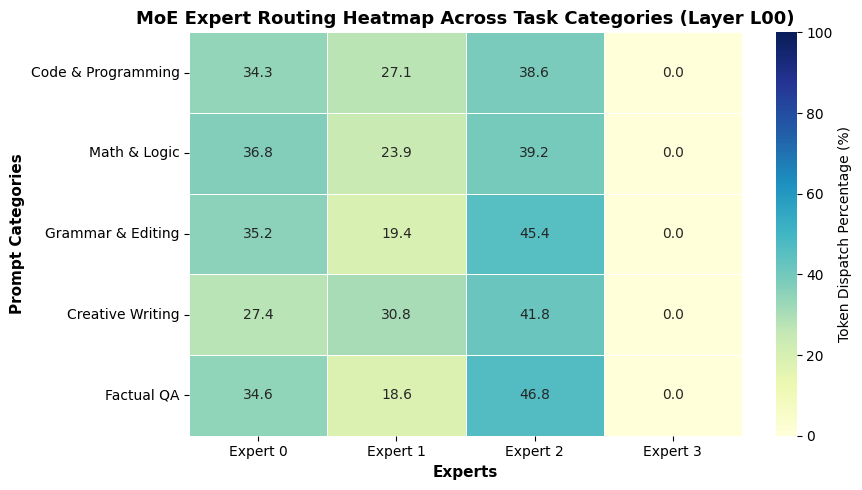

In [33]:
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

# 1. Define distinct prompt categories and sample instructions
prompt_categories = {
    "Code & Programming": [
        "Write a Python function to calculate the Fibonacci sequence.",
        "How do I parse a JSON string in JavaScript?",
        "Fix the bug in this C++ array iteration loop."
    ],
    "Math & Logic": [
        "Solve for x in the equation: 3x + 15 = 45.",
        "If all A are B and all B are C, are all A C?",
        "Calculate the probability of rolling a double six with two dice."
    ],
    "Grammar & Editing": [
        "Correct the grammar in the sentence: He do not have no money.",
        "Rephrase this sentence to sound more professional: I want to quit.",
        "Fix the spelling errors in the word: yesturday."
    ],
    "Creative Writing": [
        "Write a short poem about a quiet rainy afternoon.",
        "List three healthy snacks for a late-night movie.",
        "Draft an opening sentence for a science fiction novel."
    ],
    "Factual QA": [
        "What is the capital of Canada?",
        "Who proposed the theory of general relativity?",
        "Which planet in our solar system is the largest?"
    ]
}

def plot_moe_category_heatmap(model, tokenizer, device, target_layer=0):
    """
    Evaluates prompts across categories, logs expert choices for a target layer,
    and plots a heatmap of expert dispatch percentages.
    """
    model.eval()
    category_routing = {}
    num_experts = model.transformer.h[target_layer].mlp.num_experts

    for category, prompts in prompt_categories.items():
        category_counts = Counter()
        total_tokens = 0

        for prompt in prompts:
            # Format prompt using standard Alpaca structure
            formatted_prompt = (
                f"Below is an instruction that describes a task. "
                f"Write a response that appropriately completes the request.\n\n"
                f"### Instruction:\n{prompt}\n\n"
                f"### Response:\n"
            )

            inputs = tokenizer(formatted_prompt, return_tensors="pt").to(device)

            # Reset telemetry for the target layer
            target_mlp = model.transformer.h[target_layer].mlp
            target_mlp.routing_log = []
            target_mlp.track_routing = True

            with torch.no_grad():
                _ = model.generate(
                    **inputs,
                    max_new_tokens=30,
                    do_sample=False,
                    pad_token_id=tokenizer.eos_token_id
                )

            target_mlp.track_routing = False
            log = target_mlp.routing_log

            category_counts.update(log)
            total_tokens += len(log)

        # Calculate average dispatch percentage per expert for this category
        expert_pcts = [
            (category_counts[e] / total_tokens) * 100 if total_tokens > 0 else 0.0
            for e in range(num_experts)
        ]
        category_routing[category] = expert_pcts

    # Construct DataFrame (Rows = Categories, Cols = Experts)
    expert_labels = [f"Expert {e}" for e in range(num_experts)]
    df = pd.DataFrame(category_routing, index=expert_labels).T

    # Render Seaborn Heatmap
    plt.figure(figsize=(9, 5))
    sns.heatmap(
        df,
        annot=True,
        fmt=".1f",
        cmap="YlGnBu",
        cbar_kws={'label': 'Token Dispatch Percentage (%)'},
        linewidths=0.5,
        vmin=0,
        vmax=100
    )
    plt.title(f"MoE Expert Routing Heatmap Across Task Categories (Layer L{target_layer:02d})", fontsize=13, fontweight='bold')
    plt.xlabel("Experts", fontsize=11, fontweight='bold')
    plt.ylabel("Prompt Categories", fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return df

# Run the visualizer on Layer 0 (or change target_layer to 6 or 11)
df_l0 = plot_moe_category_heatmap(model, tokenizer, device, target_layer=0)

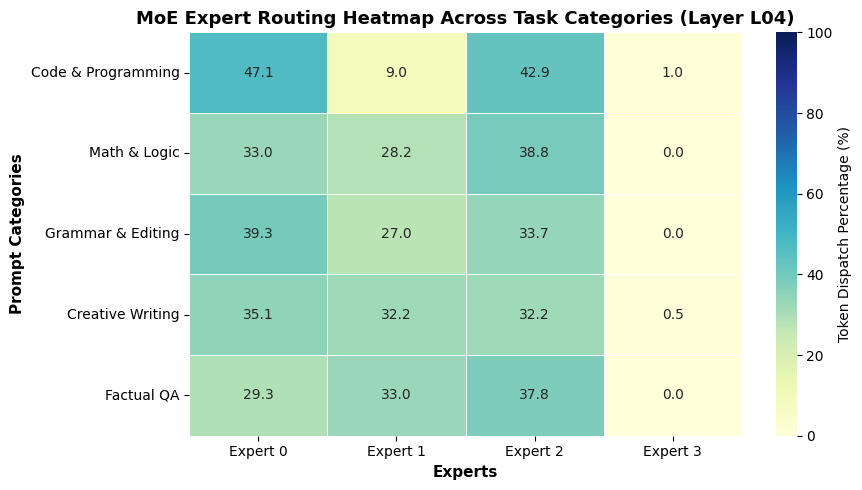

In [34]:
df_l4 = plot_moe_category_heatmap(model, tokenizer, device, target_layer=4)